In [2]:
import RFXFuse as rfx
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import matplotlib.pyplot as plt
import sklearn as sk
import os

In [3]:
folder_input = 'zillow-prize-1'
fin_train_2016 = os.path.join(folder_input, 'train_2016_v2.csv')
fin_train_2017 = os.path.join(folder_input, 'train_2017.csv')
fin_prop_2016 = os.path.join(folder_input, 'properties_2016.csv')
fin_prop_2017 = os.path.join(folder_input, 'properties_2017.csv')
fin_sample = os.path.join(folder_input, 'sample_submission.csv')

df_train_2016 = pd.read_csv(fin_train_2016)
df_train_2017 = pd.read_csv(fin_train_2017)
df_prop_2016 = pd.read_csv(fin_prop_2016, low_memory=False)
df_prop_2017 = pd.read_csv(fin_prop_2017, low_memory=False)
df_sample = pd.read_csv(fin_sample)

In [4]:
df_train_2016.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 90275 entries, 0 to 90274
Data columns (total 3 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   parcelid         90275 non-null  int64  
 1   logerror         90275 non-null  float64
 2   transactiondate  90275 non-null  object 
dtypes: float64(1), int64(1), object(1)
memory usage: 2.1+ MB


In [5]:
df_train_2016['transaction_date'] = pd.to_datetime(df_train_2016['transactiondate'])
df_train_2016['transaction_month'] = pd.to_datetime(df_train_2016['transactiondate']).dt.month

<BarContainer object of 12 artists>

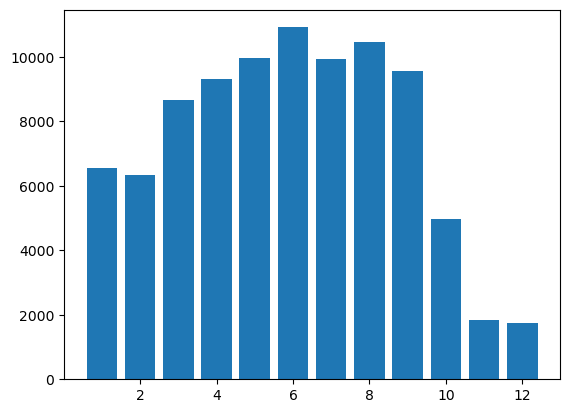

In [6]:
trans_per_month = df_train_2016['transaction_month'].value_counts().sort_index()
plt.bar(trans_per_month.index, trans_per_month.values)

In [7]:
data_types=pd.DataFrame(df_prop_2016.dtypes).reset_index()

In [8]:
data_types.columns=['column_name','data_type']
data_types.groupby(data_types.data_type)['column_name'].count()

data_type
int64       1
float64    52
object      5
Name: column_name, dtype: int64

In [9]:
df_prop_2016.isna().sum()

parcelid                              0
airconditioningtypeid           2173698
architecturalstyletypeid        2979156
basementsqft                    2983589
bathroomcnt                       11462
bedroomcnt                        11450
buildingclasstypeid             2972588
buildingqualitytypeid           1046729
calculatedbathnbr                128912
decktypeid                      2968121
finishedfloor1squarefeet        2782500
calculatedfinishedsquarefeet      55565
finishedsquarefeet12             276033
finishedsquarefeet13            2977545
finishedsquarefeet15            2794419
finishedsquarefeet50            2782500
finishedsquarefeet6             2963216
fips                              11437
fireplacecnt                    2672580
fullbathcnt                      128912
garagecarcnt                    2101950
garagetotalsqft                 2101950
hashottuborspa                  2916203
heatingorsystemtypeid           1178816
latitude                          11437


In [10]:
cols_to_drop = ['parcelid', 'logerror', 'transactiondate', 'transaction_date', 'propertycountylandusecode']

df_merge = df_train_2016.merge(df_prop_2016, on='parcelid', how='left')
# X
# 1. Drop ALL non-numeric columns
X = df_merge.select_dtypes(include=[np.number]).drop(
    ['parcelid', 'logerror'], axis=1, errors='ignore'
)
# Y
y = df_merge.logerror

In [11]:
threshold=0.9
missing_frac=X.isna().mean()

In [12]:
missing_frac

transaction_month               0.000000
airconditioningtypeid           0.681185
architecturalstyletypeid        0.997109
basementsqft                    0.999524
bathroomcnt                     0.000000
bedroomcnt                      0.000000
buildingclasstypeid             0.999823
buildingqualitytypeid           0.364564
calculatedbathnbr               0.013093
decktypeid                      0.992711
finishedfloor1squarefeet        0.924054
calculatedfinishedsquarefeet    0.007322
finishedsquarefeet12            0.051831
finishedsquarefeet13            0.999634
finishedsquarefeet15            0.960521
finishedsquarefeet50            0.924054
finishedsquarefeet6             0.995336
fips                            0.000000
fireplacecnt                    0.893581
fullbathcnt                     0.013093
garagecarcnt                    0.668380
garagetotalsqft                 0.668380
heatingorsystemtypeid           0.378787
latitude                        0.000000
longitude       

In [13]:
X=X.loc[:,missing_frac < threshold]
X=pd.get_dummies(X)

In [14]:
imputer = rfx.Imputer(n_trees=1, n_iterations=1, use_gpu=True)                                                 
X_imputed = imputer.fit_transform(X.values.astype(np.float32))

Imputer fit
  Samples: 90,275, Features: 36
  Features with missing: 25
  Categorical: 11, Numeric: 25

  Iteration 1/1
Training Random Forest Regressor with 1 trees...
GPU batch_size=1 (auto)

🚀 GPU MEMORY STATUS (After Training):
📊 GPU Memory:
   Total: 12.0 GB
   Available: 10.9 GB
   Used: 1.1 GB
   Usage: 8.8%
    Feature 31 (num): trained on 90274 samples
Training Random Forest Regressor with 1 trees...
GPU batch_size=1 (auto)

🚀 GPU MEMORY STATUS (After Training):
📊 GPU Memory:
   Total: 12.0 GB
   Available: 10.9 GB
   Used: 1.1 GB
   Usage: 9.1%
    Feature 33 (num): trained on 90274 samples
Training Random Forest Regressor with 1 trees...
GPU batch_size=1 (auto)

🚀 GPU MEMORY STATUS (After Training):
📊 GPU Memory:
   Total: 12.0 GB
   Available: 10.9 GB
   Used: 1.1 GB
   Usage: 9.4%
    Feature 34 (num): trained on 90269 samples
Training Random Forest Regressor with 1 trees...
GPU batch_size=1 (auto)

🚀 GPU MEMORY STATUS (After Training):
📊 GPU Memory:
   Total: 12.0 GB
   A

In [15]:
X_imputed=pd.DataFrame(X_imputed, columns=X.columns).dropna()

In [16]:
np.random.seed(10)
idx_shuffled=np.random.permutation(X_imputed.index.values)
idx_shuffled
n_train=int(X.shape[0]*.8)
train_idx=idx_shuffled[:n_train]
test_idx=idx_shuffled[n_train:]

X_train, y_train = X_imputed.loc[train_idx], y.loc[train_idx]
X_test, y_test = X_imputed.loc[test_idx], y.loc[test_idx]

In [17]:
print("NaNs in X:", np.isnan(X_train.values).sum())

NaNs in X: 0


In [18]:

clf = rfx.RandomForestRegressor(
            ntree=100,
            mtry=5,  # p/3 instead of sqrt(p) for better classification
            minndsize=3,  # Finer splits for large dataset
            use_casewise=True,  # Casewise importance
            use_gpu=True,
            batch_size=5,
            compute_proximity_importance=True,
            compute_local_importance=True,
            compute_leaf_assignments=True,
            iseed=42,
        )
clf.fit(X_train.values.astype(np.float32), y_train.values.astype(np.int32))  # Train on training data only (fair comparison)

print(f"OOB Error: {clf.get_oob_error()}")

# Overall Variable Importance
overall_var = clf.feature_importances_()
sorted_var = np.argsort(overall_var)[::-1]

Training Random Forest Regressor with 100 trees...
GPU batch_size=5 (manual)



🚀 GPU MEMORY STATUS (After Training):
📊 GPU Memory:
   Total: 12.0 GB
   Available: 9.5 GB
   Used: 2.5 GB
   Usage: 20.6%
OOB Error: 0.008790768682956696


In [19]:
y_pred = clf.predict(X_test.values.astype(np.float32))                                                         
mse = np.mean((y_test.values - y_pred) ** 2)  
mae = np.mean((y_test.values - y_pred))                                                               
print(f"Test MSE: {mse:.6f}")  

Test MSE: 0.028180


In [48]:
mae = np.mean((y_test.values - y_pred))                                                               
print(f"Test MAE: {mae}")

Test MAE: 0.012553344386071199


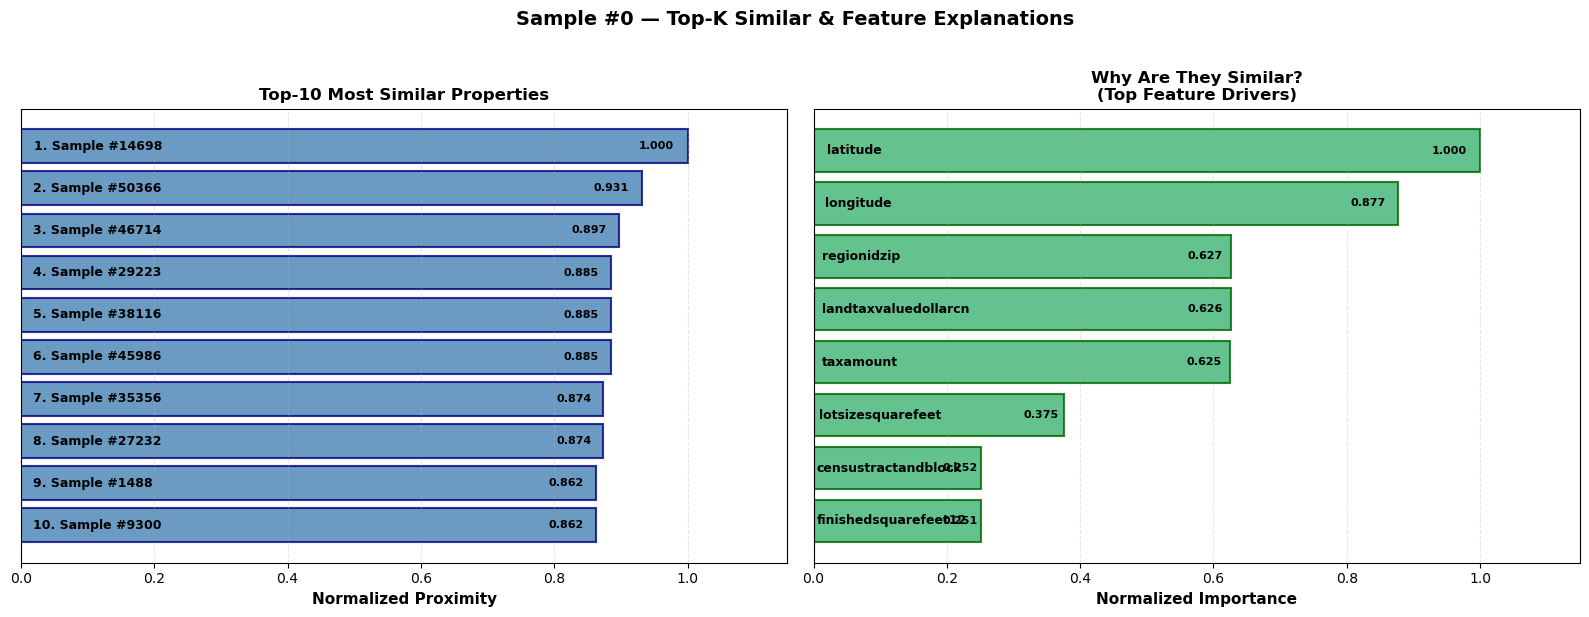

In [ ]:
  # --- Top-K Similar with Explanations ---                                                                      
  sample_idx = 0  # pick any sample to explain                                                                   
  k = 10                                                                                                         
  n_explanations = 8              
                                                                                                                 
  indices, sim_raw, sim_norm, feat_indices, feat_scores = clf.get_top_k_similar_with_explanations(               
      sample_idx, k=k, n_explanations=n_explanations
  )

  feature_names = list(X.columns)

  fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
  fig.suptitle(f'Sample #{sample_idx} — Top-K Similar & Feature Explanations',
               fontsize=14, fontweight='bold', y=1.02)

  # --- Left panel: Top-K most similar samples ---
  y_pos = np.arange(len(indices))
  bars1 = ax1.barh(y_pos, sim_norm, color='steelblue', alpha=0.8,
                   edgecolor='navy', linewidth=1.5)
  ax1.set_yticks([])
  ax1.set_xlabel('Normalized Proximity', fontsize=11, fontweight='bold')
  ax1.set_title(f'Top-{k} Most Similar Properties', fontsize=12, fontweight='bold')
  ax1.grid(axis='x', alpha=0.3, linestyle='--')
  ax1.invert_yaxis()
  ax1.set_xlim(0, max(sim_norm) * 1.15)

  for i, (bar, idx, score) in enumerate(zip(bars1, indices, sim_norm)):
      text_x = max(bar.get_width() * 0.02, 0.001)
      ax1.text(text_x, bar.get_y() + bar.get_height()/2,
               f'{i+1}. Sample #{idx}', ha='left', va='center',
               fontsize=9, fontweight='bold', color='black')
      ax1.text(bar.get_width() - bar.get_width()*0.02,
               bar.get_y() + bar.get_height()/2,
               f'{score:.3f}', ha='right', va='center',
               fontsize=8, fontweight='bold', color='black')

  # --- Right panel: Feature explanations ---
  y_pos2 = np.arange(len(feat_indices))
  feat_names = [feature_names[i][:20] if i < len(feature_names) else f'F{i}'
                for i in feat_indices]
  norm_scores = feat_scores / (feat_scores.max() + 1e-10)

  bars2 = ax2.barh(y_pos2, norm_scores, color='mediumseagreen', alpha=0.8,
                   edgecolor='darkgreen', linewidth=1.5)
  ax2.set_yticks([])
  ax2.set_xlabel('Normalized Importance', fontsize=11, fontweight='bold')
  ax2.set_title('Why Are They Similar?\n(Top Feature Drivers)', fontsize=12, fontweight='bold')
  ax2.grid(axis='x', alpha=0.3, linestyle='--')
  ax2.invert_yaxis()
  ax2.set_xlim(0, 1.15)

  for i, (bar, name, score) in enumerate(zip(bars2, feat_names, norm_scores)):
      text_x = max(bar.get_width() * 0.02, 0.001)
      ax2.text(text_x, bar.get_y() + bar.get_height()/2,
               name, ha='left', va='center',
               fontsize=9, fontweight='bold', color='black')
      ax2.text(bar.get_width() - bar.get_width()*0.02,
               bar.get_y() + bar.get_height()/2,
               f'{score:.3f}', ha='right', va='center',
               fontsize=8, fontweight='bold', color='black')

  plt.tight_layout()
  plt.show()

Top outlier: Sample #58160, score=1224.1359


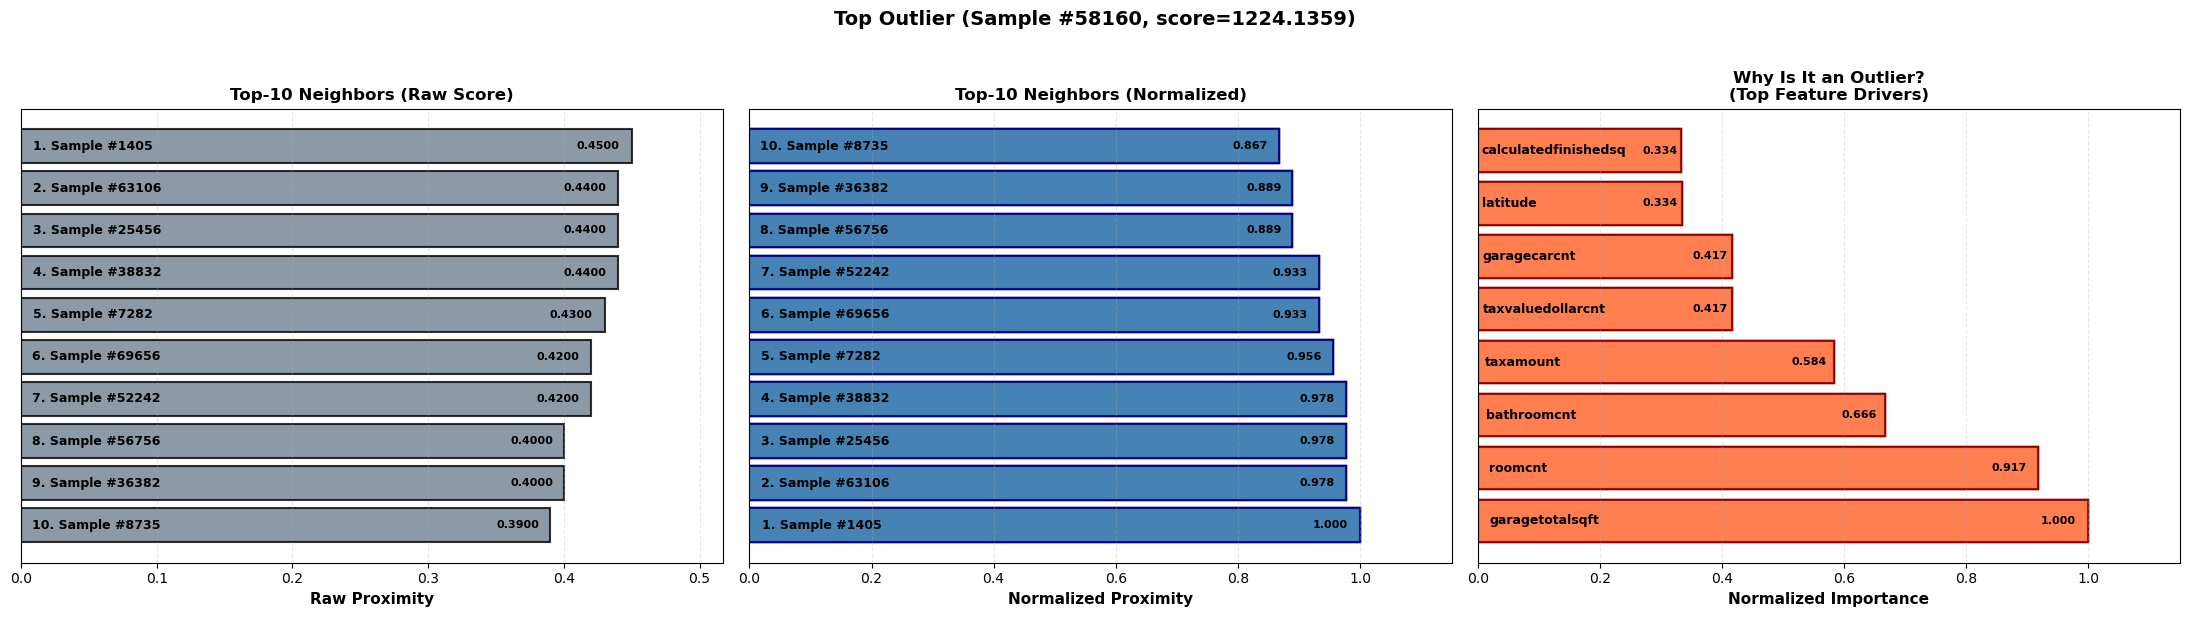

In [ ]:
outlier_scores = clf.compute_outlier_scores(mode="greedy", n_anchors=100)                                    
                                                                                                                
top_outlier_idx = np.argmax(outlier_scores)                                                                    
print(f"Top outlier: Sample #{top_outlier_idx}, score={outlier_scores[top_outlier_idx]:.4f}")                  
                                                                                                                
k = 10
n_explanations = 8

indices, sim_raw, sim_norm, feat_indices, feat_scores = clf.get_top_k_similar_with_explanations(
top_outlier_idx, k=k, n_explanations=n_explanations
)

feature_names = list(X.columns)

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(22, 6))
fig.suptitle(f'Top Outlier (Sample #{top_outlier_idx}, score={outlier_scores[top_outlier_idx]:.4f})',
        fontsize=14, fontweight='bold', y=1.02)

# Left: Raw similarity scores
y_pos = np.arange(len(indices))
bars1 = ax1.barh(y_pos, sim_raw, color='slategray', alpha=0.8,
                edgecolor='black', linewidth=1.5)
ax1.set_yticks([])
ax1.set_xlabel('Raw Proximity', fontsize=11, fontweight='bold')
ax1.set_title(f'Top-{k} Neighbors (Raw Score)', fontsize=12, fontweight='bold')
ax1.grid(axis='x', alpha=0.3, linestyle='--')
ax1.invert_yaxis()
ax1.set_xlim(0, max(sim_raw) * 1.15)

for i, (bar, idx, score) in enumerate(zip(bars1, indices, sim_raw)):
        text_x = max(bar.get_width() * 0.02, 0.001)
        ax1.text(text_x, bar.get_y() + bar.get_height()/2,
                f'{i+1}. Sample #{idx}', ha='left', va='center',
                fontsize=9, fontweight='bold', color='black')
        ax1.text(bar.get_width() - bar.get_width()*0.02,
                bar.get_y() + bar.get_height()/2,
                f'{score:.4f}', ha='right', va='center',
                fontsize=8, fontweight='bold', color='black')

        # Middle: Normalized similarity scores
        bars2 = ax2.barh(y_pos, sim_norm, color='steelblue', alpha=0.8,
                        edgecolor='navy', linewidth=1.5)
        ax2.set_yticks([])
        ax2.set_xlabel('Normalized Proximity', fontsize=11, fontweight='bold')
        ax2.set_title(f'Top-{k} Neighbors (Normalized)', fontsize=12, fontweight='bold')
        ax2.grid(axis='x', alpha=0.3, linestyle='--')
        ax2.invert_yaxis()
        ax2.set_xlim(0, max(sim_norm) * 1.15)

for i, (bar, idx, score) in enumerate(zip(bars2, indices, sim_norm)):
        text_x = max(bar.get_width() * 0.02, 0.001)
        ax2.text(text_x, bar.get_y() + bar.get_height()/2,
                f'{i+1}. Sample #{idx}', ha='left', va='center',
                fontsize=9, fontweight='bold', color='black')
        ax2.text(bar.get_width() - bar.get_width()*0.02,
                bar.get_y() + bar.get_height()/2,
                f'{score:.3f}', ha='right', va='center',
                fontsize=8, fontweight='bold', color='black')

  # Right: Feature explanations
        y_pos2 = np.arange(len(feat_indices))
        feat_names = [feature_names[i][:20] if i < len(feature_names) else f'F{i}'
                for i in feat_indices]
        norm_scores = feat_scores / (feat_scores.max() + 1e-10)

        bars3 = ax3.barh(y_pos2, norm_scores, color='coral', alpha=0.8,
                        edgecolor='darkred', linewidth=1.5)
        ax3.set_yticks([])
        ax3.set_xlabel('Normalized Importance', fontsize=11, fontweight='bold')
        ax3.set_title('Why Is It an Outlier?\n(Top Feature Drivers)', fontsize=12, fontweight='bold')
        ax3.grid(axis='x', alpha=0.3, linestyle='--')
        ax3.invert_yaxis()
        ax3.set_xlim(0, 1.15)

for i, (bar, name, score) in enumerate(zip(bars3, feat_names, norm_scores)):
        text_x = max(bar.get_width() * 0.02, 0.001)
        ax3.text(text_x, bar.get_y() + bar.get_height()/2,
                name, ha='left', va='center',
                fontsize=9, fontweight='bold', color='black')
        ax3.text(bar.get_width() - bar.get_width()*0.02,
                bar.get_y() + bar.get_height()/2,
                f'{score:.3f}', ha='right', va='center',
                fontsize=8, fontweight='bold', color='black')

plt.tight_layout()
plt.show()


In [21]:
X_props_2016 = df_prop_2016.select_dtypes(include=[np.number]).drop(['parcelid'], axis=1, errors='ignore')     
missing_frac_props = X_props_2016.isna().mean()                                                                
X_props_2016 = X_props_2016.loc[:, missing_frac_props < threshold]                                           
X_props_2016 = X_props_2016.reindex(columns=X.columns, fill_value=0)                                           
                                                                                                                
X_props_2016_imp = imputer.transform(X_props_2016.values.astype(np.float32))                                                                                                                       
                     
# Predict 2016
parcel_to_idx_2016 = {pid: i for i, pid in enumerate(df_prop_2016['parcelid'].values)}
idx_2016 = [parcel_to_idx_2016[p] for p in df_sample['ParcelId'].values]
y_pred_2016 = clf.predict(X_props_2016_imp[idx_2016].astype(np.float32))

  ✓ Transform complete! NaN remaining: 0


In [22]:
df_train_2017['transaction_month'] = pd.to_datetime(df_train_2017['transactiondate']).dt.month                 
df_merge_2017 = df_train_2017.merge(df_prop_2017, on='parcelid', how='left')                                   
X_2017 = df_merge_2017.select_dtypes(include=[np.number]).drop(['parcelid', 'logerror'], axis=1,               
errors='ignore')                                                                                        
missing_frac_2017 = X_2017.isna().mean()                                                                       
X_2017 = X_2017.loc[:, missing_frac_2017 < threshold]                                                          
X_2017 = X_2017.reindex(columns=X.columns, fill_value=0)
y_2017 = df_merge_2017.logerror

imputer_2017 = rfx.Imputer(n_trees=1, n_iterations=1, use_gpu=True)                                                 
X_2017_imp = imputer_2017.fit_transform(X_2017.values.astype(np.float32))     
clf_2017 = rfx.RandomForestRegressor(ntree=100, mtry=12, use_gpu=True, iseed=42)
clf_2017.fit(X_2017_imp.astype(np.float32), y_2017.values.astype(np.float32))
print(f"2017 OOB MSE: {clf_2017.get_oob_error():.6f}")

Imputer fit
  Samples: 77,613, Features: 36
  Features with missing: 35
  Categorical: 12, Numeric: 24

  Iteration 1/1
Training Random Forest Regressor with 1 trees...
GPU batch_size=1 (auto)

🚀 GPU MEMORY STATUS (After Training):
📊 GPU Memory:
   Total: 12.0 GB
   Available: 9.5 GB
   Used: 2.5 GB
   Usage: 20.8%
    Feature 2 (num): trained on 77579 samples
Training Random Forest Regressor with 1 trees...
GPU batch_size=1 (auto)

🚀 GPU MEMORY STATUS (After Training):
📊 GPU Memory:
   Total: 12.0 GB
   Available: 9.5 GB
   Used: 2.5 GB
   Usage: 21.1%
    Feature 3 (num): trained on 77579 samples
Training Random Forest Classifier with 1 trees...
GPU batch_size=1 (auto)

🚀 GPU MEMORY STATUS (After Training):
📊 GPU Memory:
   Total: 12.0 GB
   Available: 9.4 GB
   Used: 2.6 GB
   Usage: 21.3%
    Feature 8 (cat): trained on 77579 samples
Training Random Forest Regressor with 1 trees...
GPU batch_size=1 (auto)

🚀 GPU MEMORY STATUS (After Training):
📊 GPU Memory:
   Total: 12.0 GB
   Ava

Training Random Forest Regressor:   0%|          | 0/100 tree [00:00<?, ?tree/s]

🔧 Auto-scaling: Selected batch size = 100 trees (out of 100 total)



🚀 GPU MEMORY STATUS (After Training):
📊 GPU Memory:
   Total: 12.0 GB
   Available: 8.6 GB
   Used: 3.4 GB
   Usage: 28.6%
2017 OOB MSE: 0.029230


In [25]:
# Impute full 2017 properties + predict
X_props_2017 = df_prop_2017.select_dtypes(include=[np.number]).drop(['parcelid'], axis=1, errors='ignore')
X_props_2017 = X_props_2017.reindex(columns=X.columns, fill_value=0)
X_props_2017_imp=imputer_2017.transform(X_props_2017.values.astype(np.float32))

parcel_to_idx_2017 = {pid: i for i, pid in enumerate(df_prop_2017['parcelid'].values)}
idx_2017 = [parcel_to_idx_2017.get(p, parcel_to_idx_2016.get(p, 0)) for p in df_sample['ParcelId'].values]
y_pred_2017 = clf_2017.predict(X_props_2017_imp[idx_2017].astype(np.float32))

  ✓ Transform complete! NaN remaining: 0


In [26]:

submission = df_sample.copy()
for col in ['201610', '201611', '201612']:
    submission[col] = np.round(y_pred_2016, 4)
for col in ['201710', '201711', '201712']:
    submission[col] = np.round(y_pred_2017, 4)

submission.to_csv('submission.csv', index=False, float_format='%.4f')
print(submission.shape)
print(submission.head())

(2985217, 7)
   ParcelId  201610  201611  201612  201710  201711  201712
0  10754147  0.0138  0.0138  0.0138  0.1003  0.1003  0.1003
1  10759547  0.0063  0.0063  0.0063  0.0358  0.0358  0.0358
2  10843547  0.0077  0.0077  0.0077  0.1238  0.1238  0.1238
3  10859147  0.0466  0.0466  0.0466  0.1150  0.1150  0.1150
4  10879947  0.0319  0.0319  0.0319  0.0234  0.0234  0.0234


In [27]:
df_sample_orig = pd.read_csv(os.path.join(folder_input, 'sample_submission.csv'))                              
print(df_sample_orig.shape)  

(2985217, 7)


In [29]:
!tar -czf submission.tar.gz submission.csv                                                                     
                                              